In [27]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
import operator
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [3]:
load_dotenv()

True

In [4]:
llm = HuggingFaceEndpoint(
  repo_id="Qwen/Qwen3-Coder-Next",
  task='text-generation'
)

model = ChatHuggingFace(llm=llm)

d:\LangGraph\Sequential Workflows\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
class ChatState(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages]
  
  

In [18]:
def chat(state:ChatState):
  # take user query from state
  message = state['messages']
  
  #send to llm
  response = model.invoke(message)
  
  #store response to state
  return {"messages":[response]}

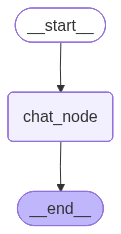

In [28]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node("chat_node", chat)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

workflow = graph.compile(checkpointer=checkpointer)

workflow


In [25]:
initial_state = {
  "messages":[HumanMessage(content="What is distance of sun and neptune?")]
}

workflow.invoke(initial_state)['messages'][1].content

'The average distance from the Sun to Neptune is about **4.5 billion kilometers** (km), or **30.1 astronomical units (AU)**.\n\n- **1 AU** = average Earth–Sun distance ≈ 149.6 million km  \n- So, 30.1 AU × 149.6 million km ≈ **4.5 billion km**\n\nBecause Neptune’s orbit is slightly elliptical (eccentricity ≈ 0.009), its distance from the Sun varies:\n- **Perihelion** (closest): ~4.46 billion km (29.8 AU)  \n- **Aphelion** (farthest): ~4.54 billion km (30.3 AU)\n\nLight takes about **4 hours and 10 minutes** to travel from the Sun to Neptune.'

In [30]:
thread_id = '1'
while True:
  
  user_message = input("Type your Query:")
  
  if user_message.strip().lower() in ['exit', 'stop', 'bye']:
    break
  
  
  config = {"configurable": {"thread_id": thread_id}}
  response = workflow.invoke({"messages":HumanMessage(content=user_message)}, config=config)
  print("AI: ", response['messages'][-1].content)

AI:  Hi Shubham! 😊  
Nice to meet you — how can I help you today? Let me know if you have any questions, need assistance with something, or just want to chat! 🌟
AI:  Your name is **Shubham**! 😊  
(And it's a beautiful name — it means *"protector"* or *"blessed"* in Sanskrit. Cool, right? 😄)

Let me know if you'd like to explore anything further — I'm here to help! 🙌
AI:  Oh, that’s lovely! 🌾  
**Madhuban, Uttar Pradesh** — it’s a small but vibrant town in the **Faizabad district** (now part of **Ayodhya district** after the 2017 reorganization). It’s located near the holy city of **Ayodhya**, which adds a deep cultural and spiritual significance to the area.

Fun fact: The name *Madhuban* literally translates to **"Honey Grove"** or **"Forest of Honey"** (*Madhu* = honey, *Ban* = forest/grove) — sounds absolutely magical, doesn’t it? 🐝🌸

Are you from there originally? Or are you currently living elsewhere? I’d love to hear more — or if you’d like, I can share interesting facts about Ma

In [31]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi my name is shubham', additional_kwargs={}, response_metadata={}, id='27215b61-55c7-40c2-aed8-5cdc55127983'), AIMessage(content='Hi Shubham! 😊  \nNice to meet you — how can I help you today? Let me know if you have any questions, need assistance with something, or just want to chat! 🌟', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 15, 'total_tokens': 59}, 'model_name': 'Qwen/Qwen3-Coder-Next', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d3a83-f72a-7030-8b1f-8f2cea8ade37-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 44, 'total_tokens': 59}), HumanMessage(content='whats my name', additional_kwargs={}, response_metadata={}, id='2612a591-6d5c-4ada-86ad-7676a1fbbe9a'), AIMessage(content='Your name is **Shubham**! 😊  \n(And it\'s a beautiful name — it means *"protector"* or *"blessed"* in San